## Preprocessing Technique Comparison

Evaluates the effect of different preprocessing choices on bounding box regression (IoU / MSE).  
The main pipeline is **not modified** — this notebook loads the already-saved `.npy` files and tries alternatives.

Three categories are tested:
1. **Feature scaling** — how pixel values are normalized before feature extraction  
2. **Dimensionality reduction** — PCA component counts after HOG  
3. **Feature extraction (skimage)** — HOG vs. LBP vs. raw pixels  

A fixed ExtraTreesRegressor (200 trees, best params from the main notebook) is used throughout so differences are attributable to preprocessing alone.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog, local_binary_pattern
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [12]:
X = np.load('../preprocessed_data/images.npy')       # (N, 224, 224, 3), already in [0, 1]
Y = np.load('../preprocessed_data/bboxes.npy')       # (N, 4)
train_idx = np.load('../preprocessed_data/train_indices.npy')
test_idx  = np.load('../preprocessed_data/test_indices.npy')

y_train, y_test = Y[train_idx], Y[test_idx]
print(f'Train: {len(train_idx)} | Test: {len(test_idx)}')

Train: 2580 | Test: 738


### Shared helpers

In [13]:
def iou(actual, pred):
    x1, y1, w1, h1 = actual
    x2, y2, w2, h2 = pred
    w_i = min(x1 + w1, x2 + w2) - max(x1, x2)
    h_i = min(y1 + h1, y2 + h2) - max(y1, y2)
    if w_i <= 0 or h_i <= 0:
        return 0.0
    inter = w_i * h_i
    return inter / (w1 * h1 + w2 * h2 - inter)

def mean_iou(y_true, y_pred):
    return float(np.mean([iou(y_true[i], y_pred[i]) for i in range(len(y_true))]))

def extract_hog(images):
    return np.array([
        hog(img, orientations=8, pixels_per_cell=(16, 16),
            cells_per_block=(2, 2), channel_axis=-1)
        for img in images
    ])

def extract_lbp(images, P=24, R=3):
    feats = []
    for img in images:
        gray = img.mean(axis=-1)           # (224, 224)
        lbp  = local_binary_pattern(gray, P, R, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=P + 2, range=(0, P + 2), density=True)
        feats.append(hist)
    return np.array(feats)

def evaluate(label, X_tr, X_te, n_pca=200):
    """Fit PCA + ExtraTrees on X_tr, evaluate on X_te. Returns result dict."""
    steps = []
    if n_pca is not None and n_pca < X_tr.shape[1]:
        steps.append(('pca', PCA(n_components=n_pca, random_state=42)))
    steps.append(('et', ExtraTreesRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=42, n_jobs=-1
    )))
    pipe = Pipeline(steps)
    pipe.fit(X_tr, y_train)

    train_iou = mean_iou(y_train, pipe.predict(X_tr))
    pred_test = pipe.predict(X_te)
    test_iou  = mean_iou(y_test, pred_test)
    test_mse  = float(np.mean((y_test - pred_test) ** 2))

    print(f'  {label:<45} train IoU={train_iou:.3f}  test IoU={test_iou:.3f}  MSE={test_mse:.1f}')
    return {'variant': label, 'train_iou': train_iou, 'test_iou': test_iou, 'test_mse': test_mse}

results = []

---
## 1. Feature Scaling

All variants use the same HOG extractor and PCA(200). Only the pixel normalization differs.

| Variant | Description |
|---|---|
| `[0, 1]` baseline | Current pipeline — pixel values divided by 255 |
| `[-1, 1]` rescale | Linear stretch to [-1, 1]: `img * 2 - 1` |
| StandardScaler (pixels) | Per-channel zero mean / unit variance applied before HOG |
| StandardScaler (HOG) | HOG features are standardized after extraction |

In [14]:
print('Extracting HOG on [0,1] images (baseline)...')
hog_01_train = extract_hog(X[train_idx])
hog_01_test  = extract_hog(X[test_idx])
results.append(evaluate('[0,1] → HOG → PCA(200)  (baseline)', hog_01_train, hog_01_test))

print('Extracting HOG on [-1,1] rescaled images...')
X_pm1 = X * 2.0 - 1.0
hog_pm1_train = extract_hog(X_pm1[train_idx])
hog_pm1_test  = extract_hog(X_pm1[test_idx])
results.append(evaluate('[-1,1] → HOG → PCA(200)', hog_pm1_train, hog_pm1_test))

print('Extracting HOG on StandardScaler-normalized images (per pixel, per channel)...')
flat_train = X[train_idx].reshape(len(train_idx), -1).astype(np.float32)
flat_test  = X[test_idx].reshape(len(test_idx), -1).astype(np.float32)
sc_pix = StandardScaler()
sc_pix.fit(flat_train)
X_sc_train = sc_pix.transform(flat_train).reshape(len(train_idx), 224, 224, 3)
X_sc_test  = sc_pix.transform(flat_test).reshape(len(test_idx), 224, 224, 3)
hog_sc_train = extract_hog(X_sc_train)
hog_sc_test  = extract_hog(X_sc_test)
results.append(evaluate('StandardScaler(pixels) → HOG → PCA(200)', hog_sc_train, hog_sc_test))

print('Standardizing HOG features after extraction...')
sc_hog = StandardScaler()
hog_sc_hog_train = sc_hog.fit_transform(hog_01_train)
hog_sc_hog_test  = sc_hog.transform(hog_01_test)
results.append(evaluate('[0,1] → HOG → StandardScaler(HOG) → PCA(200)', hog_sc_hog_train, hog_sc_hog_test))

Extracting HOG on [0,1] images (baseline)...
  [0,1] → HOG → PCA(200)  (baseline)            train IoU=1.000  test IoU=0.393  MSE=992.9
Extracting HOG on [-1,1] rescaled images...
  [-1,1] → HOG → PCA(200)                       train IoU=1.000  test IoU=0.394  MSE=990.5
Extracting HOG on StandardScaler-normalized images (per pixel, per channel)...
  StandardScaler(pixels) → HOG → PCA(200)       train IoU=1.000  test IoU=0.395  MSE=993.9
Standardizing HOG features after extraction...
  [0,1] → HOG → StandardScaler(HOG) → PCA(200)  train IoU=1.000  test IoU=0.392  MSE=1003.5


---
## 2. Dimensionality Reduction

Fixed `[0,1]` baseline images and HOG features (5408-dim). PCA component count is varied.  
One variant skips PCA entirely to show the effect of keeping all features.

In [15]:
for n in [50, 100, 200, 500]:
    results.append(evaluate(f'[0,1] → HOG → PCA({n})', hog_01_train, hog_01_test, n_pca=n))

# No PCA — pass all 5408 HOG features directly
results.append(evaluate('[0,1] → HOG → no PCA (5408 features)', hog_01_train, hog_01_test, n_pca=None))

  [0,1] → HOG → PCA(50)                         train IoU=1.000  test IoU=0.403  MSE=944.4
  [0,1] → HOG → PCA(100)                        train IoU=1.000  test IoU=0.399  MSE=978.2
  [0,1] → HOG → PCA(200)                        train IoU=1.000  test IoU=0.393  MSE=992.9
  [0,1] → HOG → PCA(500)                        train IoU=1.000  test IoU=0.391  MSE=1020.1
  [0,1] → HOG → no PCA (5408 features)          train IoU=1.000  test IoU=0.394  MSE=1013.4


---
## 3. Feature Extraction (skimage)

Different feature descriptors extracted from `[0,1]` images, each followed by PCA(200).

| Variant | Description |
|---|---|
| HOG | Histogram of Oriented Gradients — captures edge/shape structure |
| LBP | Local Binary Patterns — captures texture |
| HOG + LBP | Concatenation of both descriptors |
| Raw pixels | Flattened pixel values — no hand-crafted features |

In [16]:
# HOG already computed above — re-use it
results.append(evaluate('[0,1] → HOG → PCA(200)', hog_01_train, hog_01_test))

print('Extracting LBP features...')
lbp_train = extract_lbp(X[train_idx])
lbp_test  = extract_lbp(X[test_idx])
results.append(evaluate('[0,1] → LBP → PCA(200)', lbp_train, lbp_test))

print('Concatenating HOG + LBP features...')
hog_lbp_train = np.hstack([hog_01_train, lbp_train])
hog_lbp_test  = np.hstack([hog_01_test, lbp_test])
results.append(evaluate('[0,1] → HOG+LBP → PCA(200)', hog_lbp_train, hog_lbp_test))

print('Using raw flattened pixels...')
raw_train = X[train_idx].reshape(len(train_idx), -1).astype(np.float32)
raw_test  = X[test_idx].reshape(len(test_idx), -1).astype(np.float32)
results.append(evaluate('[0,1] → raw pixels → PCA(200)', raw_train, raw_test))

  [0,1] → HOG → PCA(200)                        train IoU=1.000  test IoU=0.393  MSE=992.9
Extracting LBP features...


/Users/charlie/.pyenv/versions/3.13.7/lib/python3.13/site-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


  [0,1] → LBP → PCA(200)                        train IoU=1.000  test IoU=0.379  MSE=1113.9
Concatenating HOG + LBP features...
  [0,1] → HOG+LBP → PCA(200)                    train IoU=1.000  test IoU=0.393  MSE=993.8
Using raw flattened pixels...
  [0,1] → raw pixels → PCA(200)                 train IoU=1.000  test IoU=0.379  MSE=1135.7


---
## Summary

In [17]:
scaling_df    = pd.DataFrame(results[0:4])
dimred_df     = pd.DataFrame(results[4:9])
extraction_df = pd.DataFrame(results[9:])

summary = pd.DataFrame([
    {'Method': 'Feature Scaling',         'Best Variant': scaling_df.loc[scaling_df['test_iou'].idxmax(), 'variant'],    'Test IoU': scaling_df['test_iou'].max(),    'Test MSE': scaling_df.loc[scaling_df['test_iou'].idxmax(), 'test_mse']},
    {'Method': 'Dimensionality Reduction','Best Variant': dimred_df.loc[dimred_df['test_iou'].idxmax(), 'variant'],      'Test IoU': dimred_df['test_iou'].max(),      'Test MSE': dimred_df.loc[dimred_df['test_iou'].idxmax(), 'test_mse']},
    {'Method': 'Feature Extraction',      'Best Variant': extraction_df.loc[extraction_df['test_iou'].idxmax(), 'variant'], 'Test IoU': extraction_df['test_iou'].max(), 'Test MSE': extraction_df.loc[extraction_df['test_iou'].idxmax(), 'test_mse']},
])

summary.style.format({'Test IoU': '{:.3f}', 'Test MSE': '{:.1f}'}) \
             .background_gradient(subset='Test IoU', cmap='RdYlGn') \
             .hide(axis='index')

Method,Best Variant,Test IoU,Test MSE
Feature Scaling,StandardScaler(pixels) → HOG → PCA(200),0.395,993.9
Dimensionality Reduction,"[0,1] → HOG → PCA(50)",0.403,944.4
Feature Extraction,"[0,1] → HOG → PCA(200)",0.393,992.9


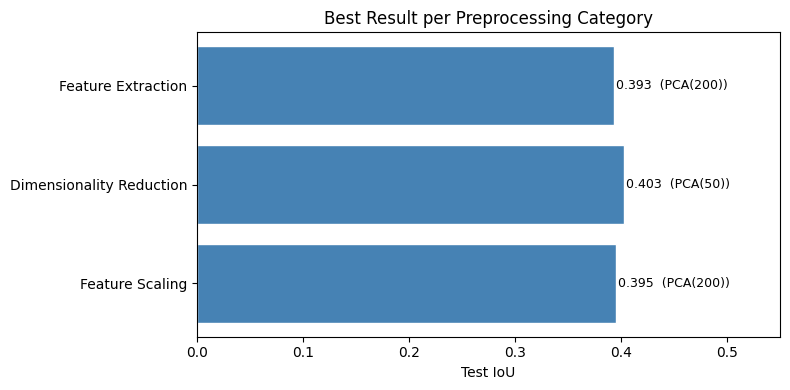

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(summary['Method'], summary['Test IoU'], color=['steelblue', 'steelblue', 'steelblue'], edgecolor='white')
for i, (iou, variant) in enumerate(zip(summary['Test IoU'], summary['Best Variant'])):
    label = variant.split('→')[-1].strip() if '→' in variant else variant
    ax.text(iou + 0.002, i, f'{iou:.3f}  ({label})', va='center', fontsize=9)

ax.set_xlabel('Test IoU')
ax.set_xlim(0, 0.55)
ax.set_title('Best Result per Preprocessing Category')
plt.tight_layout()
plt.show()